In [1]:
from RRTG_helpers import *
import pandas as pd
import numpy as np
import c_graph_lib.bin.tourny as tou

In [2]:
df = pd.read_csv("../Data/mlb_division_series_results.csv")
df = df.drop(columns=["league", "games_played", "ties", "wins2", "wins1"])
df

,season,division,team1,team2,result
0,1985,AL-East,BAL,BOS,BOS
1,1985,AL-East,BAL,CLE,BAL
2,1985,AL-East,BAL,DET,DET
3,1985,AL-East,BAL,MIL,BAL
4,1985,AL-East,BAL,NYA,NYA
...,...,...,...,...,...
2498,2024,NL-West,COL,SDN,COL
2499,2024,NL-West,COL,SFN,SFN
2500,2024,NL-West,LAN,SDN,SDN
2501,2024,NL-West,LAN,SFN,LAN


In [3]:
div_list = 	["AL-Central", "AL-East", "AL-West", "NL-Central", "NL-East", "NL-West"]

In [4]:
def df_to_tg(df: pd.DataFrame) -> DiGraph:
    
    tg_name: str = f"{df.iloc[int(0)]["division"]} {df.iloc[int(0)]["season"]}"
    edge_list: list[tuple[str, str]] = [
        (row["team1"], row["team2"]) if row["team1"] == row["result"]
        else (row["team2"], row["team1"])
        for (index, row) in df.iterrows()
    ]
    return DiGraph(edge_list,
                   data_structure="static_sparse", 
                   format="list_of_edges", 
                   name=tg_name)

In [5]:
df_year_list = list()
for i in range(1985, 2025):
    for div in div_list:
        tmp_df = df[(df["division"]==div) & (df["season"]==i)]
        if not tmp_df.empty:
            df_year_list.append(tmp_df)

tg_year_list = map(df_to_tg, df_year_list)
test = df_year_list[0]
test

,season,division,team1,team2,result
0,1985,AL-East,BAL,BOS,BOS
1,1985,AL-East,BAL,CLE,BAL
2,1985,AL-East,BAL,DET,DET
3,1985,AL-East,BAL,MIL,BAL
4,1985,AL-East,BAL,NYA,NYA
5,1985,AL-East,BAL,TOR,TOR
6,1985,AL-East,BOS,CLE,BOS
7,1985,AL-East,BOS,DET,DET
8,1985,AL-East,BOS,MIL,MIL
9,1985,AL-East,BOS,NYA,NYA


In [6]:
g = df_to_tg(test)

In [7]:
tourny_dict = {TG : list() for TG in digraphs.tournaments_nauty(5, immutable=True)}
tourny_dict

{Digraph on 5 vertices: [],
 Digraph on 5 vertices: [],
 Digraph on 5 vertices: [],
 Digraph on 5 vertices: [],
 Digraph on 5 vertices: [],
 Digraph on 5 vertices: [],
 Digraph on 5 vertices: [],
 Digraph on 5 vertices: [],
 Digraph on 5 vertices: [],
 Digraph on 5 vertices: [],
 Digraph on 5 vertices: [],
 Digraph on 5 vertices: []}

In [8]:
for MLB_TG in tg_year_list:
    for g in tourny_dict:
        if MLB_TG.is_isomorphic(g):
            tourny_dict[g].append(MLB_TG)
            break

In [9]:
tourny_stats = [(g, len(tourny_dict[g]), num_upsets(g)) for g in tourny_dict]
tourny_stats

[(Digraph on 5 vertices, 50, 0),
 (Digraph on 5 vertices, 13, 0),
 (Digraph on 5 vertices, 22, 1),
 (Digraph on 5 vertices, 6, 2),
 (Digraph on 5 vertices, 7, 2),
 (Digraph on 5 vertices, 7, 2),
 (Digraph on 5 vertices, 7, 1),
 (Digraph on 5 vertices, 0, 0),
 (Digraph on 5 vertices, 17, 0),
 (Digraph on 5 vertices, 3, 1),
 (Digraph on 5 vertices, 11, 1),
 (Digraph on 5 vertices, 5, 0)]

In [10]:
from sage.repl.ipython_kernel.interact import interact, sage_interactive
@interact
def _(iso_class=sage_interactive.widget_from_iterable(tourny_stats)):
    @interact
    def __(MLB_Graph=sage_interactive.widget_from_iterable(tourny_dict[iso_class[0]])):
        if not MLB_Graph is None:
            upsets, not_upsets = str_upsets_not_upsets(MLB_Graph)
            MLB_Graph.show(
                vertex_size=700,
                edge_colors={'red' : upsets, 'navy' : not_upsets}
            )
        else:
            show(None)

Interactive function <function _ at 0x7239083d09a0> with 1 widget
  iso_class: Dropdown(description='iso_class', options=((Digraph on 5 vertices, 50, 0), (Digraph on 5 vertices, 13, 0), (Digraph on 5 vertices, 22, 1), (Digraph on 5 vertices, 6, 2), (Digraph on 5 vertices, 7, 2), (Digraph on 5 vertices, 7, 2), (Digraph on 5 vertices, 7, 1), (Digraph on 5 vertices, 0, 0), (Digraph on 5 vertices, 17, 0), (Digraph on 5 vertices, 3, 1), (Digraph on 5 vertices, 11, 1), (Digraph on 5 vertices, 5, 0)), value=(Digraph on 5 vertices, 50, 0))

### Histogram

In [12]:
mlb_upset_list = list()
full_list_upsets = list(tou.upset_generator(int(n), int(0)))

for g, n, u in tourny_stats:
    mlb_upset_list += ([u] * n)

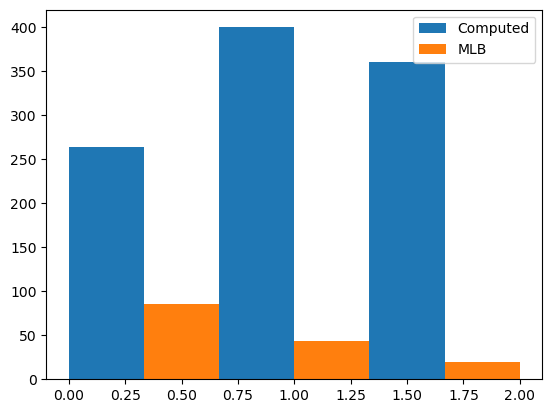

In [13]:
import matplotlib.pyplot as plt

plt.hist([full_list_upsets, mlb_upset_list], bins=3, label=['Computed', 'MLB'], align="mid", rwidth=1.0)
plt.legend(loc='upper right')
plt.show()

Let $X$ be the random variable which uniformly selects from the unquotented sample space of all tournoment graphs of order $5$.

Let $X_{MLB}$ be the random variable with the same sample sapce with probablity based in our MLB data.

Let $\phi(G)$ denote the number of upsets in $G$.

In [14]:
%display latex
show(LatexExpr(f"var\\bigg(\\phi(X_{{MLB}})\\bigg) = {np.var(mlb_upset_list)},\\ \\mathbb E \\bigg(\\phi(X_{{MLB}})\\bigg) = {np.mean(mlb_upset_list)}"))
show(LatexExpr(f"var\\bigg(\\phi(X)\\bigg) = {np.var(full_list_upsets)},\\ \\mathbb E \\bigg(\\phi(X)\\bigg) = {np.mean(full_list_upsets)}"))
%display plain

var\bigg(\phi(X_{MLB})\bigg) = 0.516572315558802,\ \mathbb E \bigg(\phi(X_{MLB})\bigg) = 0.5608108108108109

var\bigg(\phi(X)\bigg) = 0.6005859375,\ \mathbb E \bigg(\phi(X)\bigg) = 1.09375

### Scatter Plot
The following scatter plot has isomorphism classes as points with an $y$-axis correspoinding to the number of occurences in the data and a $x$-axis corresponding to the number of cylces in the representative graph.

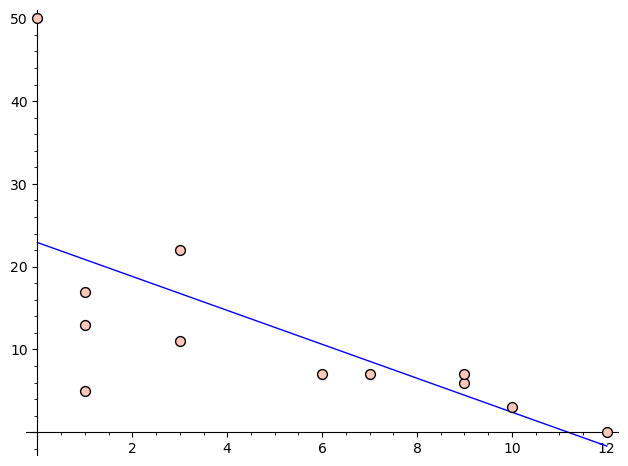

In [15]:
cycles_count_list = [(len(list(g.all_simple_cycles())), len(tourny_dict[g])) for g in tourny_dict]
x_list, y_list = ([p[0] for p in cycles_count_list], [p[1] for p in cycles_count_list])

m, b = np.polyfit(x_list, y_list, deg=1)
m, b

scatter_plot(cycles_count_list, ) + plot(m*x + b, (0,12))

Let $c(G)$ denote the number of cycles in a tournoment $G$

In [16]:
%display latex
show(LatexExpr(f"corr\\bigg(c(X_{{MLB}}),X_{{MLB}}\\bigg) = {np.corrcoef(x_list, y_list)[1][0]}"))
%display plain

corr\bigg(c(X_{MLB}),X_{MLB}\bigg) = -0.6415261846116963